# Model Comparison — Inflation Forecasting

Loads saved test predictions from each model notebook and compares performance
on the **same held-out test period** using identical metrics.

**Run order (required before this notebook):**
1. `inflation_forecasting_elasticnet.ipynb` — saves `results/elasticnet_preds.npy`
2. `inflation_forecasting_rnn.ipynb` — saves `results/rnn_preds.npy`
3. `inflation_forecasting_ols.ipynb` — saves `results/ar_ols_preds.npy`, `results/naive_preds.npy`
4. `inflation_forecasting_gbt.ipynb` — saves `results/gbt_preds.npy`
5. `ensemble_soft_voting.ipynb` — saves `results/soft_voting_preds.npy`

All metrics are on the **transformed scale**: monthly log-diff × 100  
(percentage points of monthly PCE inflation). RMSE = 0.10 means forecasts  
are off by 0.10 pp per month on average.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from fred_md_utils import configure_plots, default_paths

configure_plots()
_, RESULTS_DIR = default_paths()


## Load Saved Predictions

In [2]:
def load_model_results(results_dir, model_key, dates_key=None, actuals_key=None):
    """Load predictions (and optionally dates/actuals) saved by a model notebook."""
    preds_path = os.path.join(results_dir, f'{model_key}_preds.npy')
    if not os.path.exists(preds_path):
        raise FileNotFoundError(
            f"Missing {preds_path}. Run the {model_key} notebook first."
        )
    preds = np.load(preds_path)
    dates = None
    actuals = None
    if dates_key:
        d_path = os.path.join(results_dir, f'{dates_key}_dates.npy')
        if os.path.exists(d_path):
            dates = pd.DatetimeIndex(np.load(d_path).astype('datetime64[ns]'))
    if actuals_key:
        a_path = os.path.join(results_dir, f'{actuals_key}_actuals.npy')
        if os.path.exists(a_path):
            actuals = np.load(a_path)
    return preds, dates, actuals


# -- ElasticNet --
en_preds, en_dates, _ = load_model_results(RESULTS_DIR, 'elasticnet', dates_key='elasticnet')
y_test = np.load(os.path.join(RESULTS_DIR, 'y_test.npy'))
y_test_dates = pd.DatetimeIndex(
    np.load(os.path.join(RESULTS_DIR, 'y_test_dates.npy')).astype('datetime64[ns]')
)

# -- RNN (LSTM) --
rnn_preds, rnn_dates, rnn_actuals = load_model_results(
    RESULTS_DIR, 'rnn', dates_key='rnn', actuals_key='rnn'
)

# -- AR-OLS + Naive RW (OLS baselines notebook) --
ar_ols_preds, ar_ols_dates, _ = load_model_results(RESULTS_DIR, 'ar_ols', dates_key='ar_ols')
naive_preds,  naive_dates,  _ = load_model_results(RESULTS_DIR, 'naive',  dates_key='naive')

# -- Gradient Boosted Trees --
gbt_preds, gbt_dates, _ = load_model_results(RESULTS_DIR, 'gbt', dates_key='gbt')

# -- Soft Voting Ensemble --
sv_preds,  sv_dates,  _ = load_model_results(RESULTS_DIR, 'soft_voting', dates_key='soft_voting')

print(f"ElasticNet predictions : {len(en_preds)}  "
      f"({y_test_dates.min().date()} -> {y_test_dates.max().date()})")
print(f"RNN predictions        : {len(rnn_preds)}  "
      f"({rnn_dates.min().date()} -> {rnn_dates.max().date()})")
print(f"AR-OLS predictions     : {len(ar_ols_preds)}  "
      f"({ar_ols_dates.min().date()} -> {ar_ols_dates.max().date()})")
print(f"Naive predictions      : {len(naive_preds)}  "
      f"({naive_dates.min().date()} -> {naive_dates.max().date()})")
print(f"GBT predictions        : {len(gbt_preds)}  "
      f"({gbt_dates.min().date()} -> {gbt_dates.max().date()})")
print(f"Soft-Voting predictions: {len(sv_preds)}  "
      f"({sv_dates.min().date()} -> {sv_dates.max().date()})")


ElasticNet predictions : 7  (2025-06-01 -> 2025-12-01)
RNN predictions        : 7  (2025-06-01 -> 2025-12-01)
AR-OLS predictions     : 7  (2025-06-01 -> 2025-12-01)
Naive predictions      : 7  (2025-06-01 -> 2025-12-01)
GBT predictions        : 7  (2025-06-01 -> 2025-12-01)
Soft-Voting predictions: 7  (2025-06-01 -> 2025-12-01)


## Align Test Windows

The ElasticNet and RNN test sets may start on different dates: the RNN drops  
the first `SEQ_LEN - 1` test rows to build its initial context window.  
We compare only on the overlapping period.


In [3]:
# Build date-indexed Series for each model
en_series     = pd.Series(en_preds,     index=y_test_dates, name='ElasticNet')
rnn_series    = pd.Series(rnn_preds,    index=rnn_dates,    name='LSTM')
ar_ols_series = pd.Series(ar_ols_preds, index=ar_ols_dates, name='AR-OLS')
naive_series  = pd.Series(naive_preds,  index=naive_dates,  name='Naive')
gbt_series    = pd.Series(gbt_preds,    index=gbt_dates,    name='GBT')
sv_series     = pd.Series(sv_preds,     index=sv_dates,     name='Soft Voting')

actual_series = pd.Series(y_test, index=y_test_dates, name='Actual')

# Align all on the RNN's (shortest) test window so every model has a prediction.
common_dates = rnn_dates

actual_aligned  = actual_series.reindex(common_dates)
en_aligned      = en_series.reindex(common_dates)
rnn_aligned     = rnn_series.reindex(common_dates)
ar_ols_aligned  = ar_ols_series.reindex(common_dates)
naive_aligned   = naive_series.reindex(common_dates)
gbt_aligned     = gbt_series.reindex(common_dates)
sv_aligned      = sv_series.reindex(common_dates)

print(f"Comparison window: {common_dates.min().date()} to {common_dates.max().date()}")
print(f"Observations: {len(common_dates)}")


Comparison window: 2025-06-01 to 2025-12-01
Observations: 7


## Compare Models

In [4]:
def compare_models(predictions_dict, y_true):
    """Compare model predictions against ground truth; returns DataFrame sorted by RMSE."""
    y_true = np.asarray(y_true)
    rows = []
    for name, y_pred in predictions_dict.items():
        y_pred = np.asarray(y_pred)
        rows.append({
            'Model':    name,
            'RMSE':     float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAE':      float(mean_absolute_error(y_true, y_pred)),
            'R²':   float(r2_score(y_true, y_pred)),
            'MAPE (%)': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
        })
    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)


results_df = compare_models(
    {
        'ElasticNet': en_aligned.values,
        'LSTM':       rnn_aligned.values,
        'AR-OLS':     ar_ols_aligned.values,
        'Naive RW':   naive_aligned.values,
        'GBT':        gbt_aligned.values,
        'Soft Voting': sv_aligned.values,
    },
    actual_aligned.values,
)

print(f"Test period : {common_dates.min().date()} to {common_dates.max().date()}")
print(f"n obs       : {len(common_dates)}")
print()
print("Metrics scale: monthly log-diff x 100 (pp of monthly PCE inflation)")
print()
print(results_df.to_string(index=False, float_format='{:.4f}'.format))


Test period : 2025-06-01 to 2025-12-01
n obs       : 7

Metrics scale: monthly log-diff x 100 (pp of monthly PCE inflation)

      Model   RMSE    MAE      R²  MAPE (%)
     AR-OLS 0.0545 0.0420  0.0874   16.2219
 ElasticNet 0.0642 0.0510 -0.2640   19.6195
        GBT 0.0767 0.0662 -0.8058   26.6531
   Naive RW 0.0801 0.0646 -0.9664   24.1647
Soft Voting 0.1013 0.0890 -2.1450   34.0110
       LSTM 0.1042 0.0833 -2.3312   32.7393


## RMSE Bar Chart

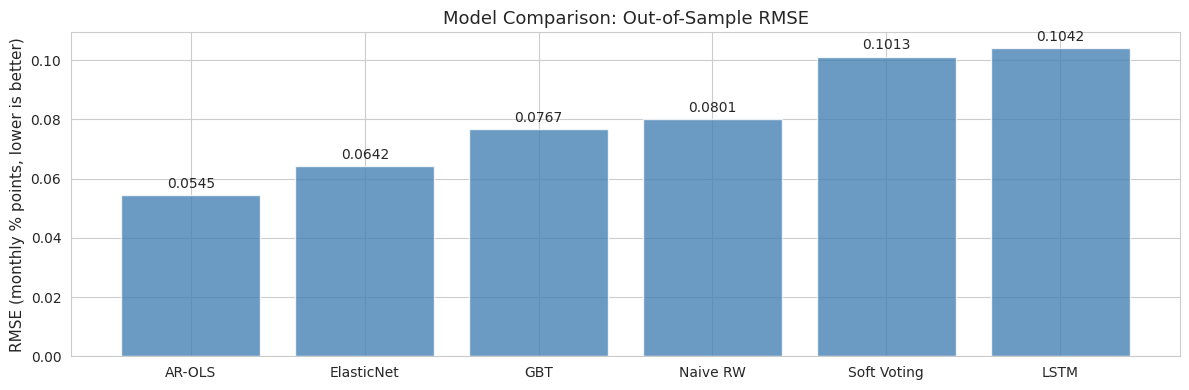

In [5]:
fig, ax = plt.subplots(figsize=(max(5, len(results_df) * 2), 4))
bars = ax.bar(results_df['Model'], results_df['RMSE'],
              color='steelblue', alpha=0.8, edgecolor='white')
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=10)
ax.set_ylabel('RMSE (monthly % points, lower is better)')
ax.set_title('Model Comparison: Out-of-Sample RMSE')
fig.tight_layout()
plt.show()


## Overlay Plot: Actuals vs All Models

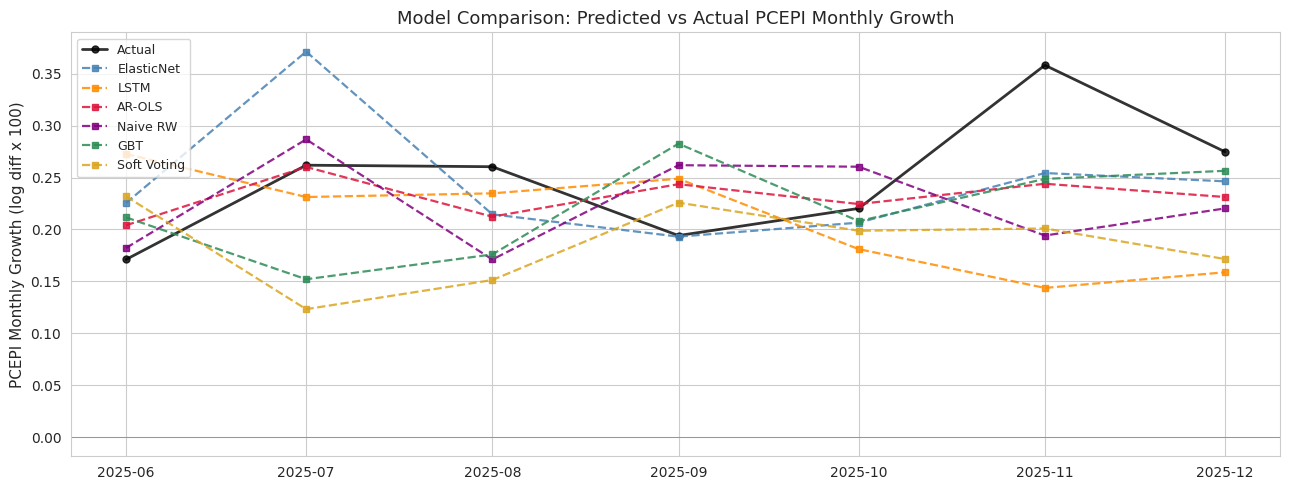

In [6]:
colors = {
    'ElasticNet':  'steelblue',
    'LSTM':        'darkorange',
    'AR-OLS':      'crimson',
    'Naive RW':    'purple',
    'GBT':         'seagreen',
    'Soft Voting': 'goldenrod',
}

fig, ax = plt.subplots(figsize=(13, 5))
configure_plots()
ax.plot(common_dates, actual_aligned.values,
        'o-', label='Actual', linewidth=2, markersize=5, color='black', alpha=0.8)

model_series = {
    'ElasticNet':  en_aligned.values,
    'LSTM':        rnn_aligned.values,
    'AR-OLS':      ar_ols_aligned.values,
    'Naive RW':    naive_aligned.values,
    'GBT':         gbt_aligned.values,
    'Soft Voting': sv_aligned.values,
}
for name, preds in model_series.items():
    ax.plot(common_dates, preds, 's--',
            label=name, linewidth=1.6, markersize=4,
            color=colors[name], alpha=0.85)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('Model Comparison: Predicted vs Actual PCEPI Monthly Growth')
ax.set_ylabel('PCEPI Monthly Growth (log diff x 100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.tight_layout()
plt.show()


## Residuals

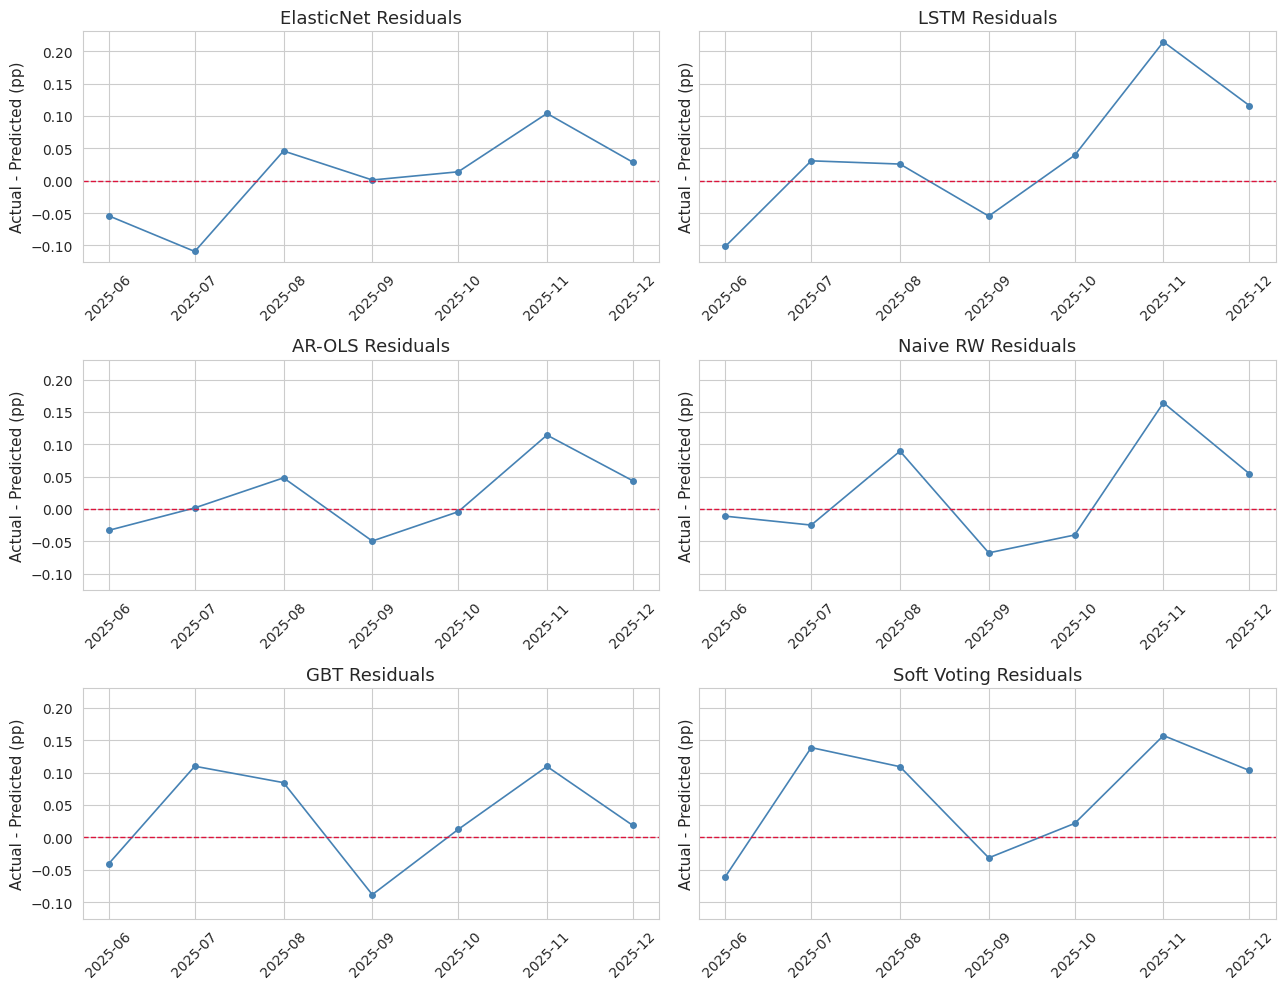

In [7]:
model_series = {
    'ElasticNet':  en_aligned.values,
    'LSTM':        rnn_aligned.values,
    'AR-OLS':      ar_ols_aligned.values,
    'Naive RW':    naive_aligned.values,
    'GBT':         gbt_aligned.values,
    'Soft Voting': sv_aligned.values,
}

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharey=True)
flat_axes = axes.flatten()
for ax, (name, preds) in zip(flat_axes, model_series.items()):
    residuals = actual_aligned.values - preds
    ax.plot(common_dates, residuals, 'o-', linewidth=1.2, markersize=4, color='steelblue')
    ax.axhline(0, color='crimson', linewidth=1, linestyle='--')
    ax.set_title(f'{name} Residuals')
    ax.set_ylabel('Actual - Predicted (pp)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()
